In [1]:
import os
import sys
src_dir = "../../src"
if src_dir not in sys.path:
    sys.path.append(src_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list
from utils import normalize_angles, lla_to_enu, ecef_to_lla, get_rigid_transformation
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm


%matplotlib inline
np.random.seed(777)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


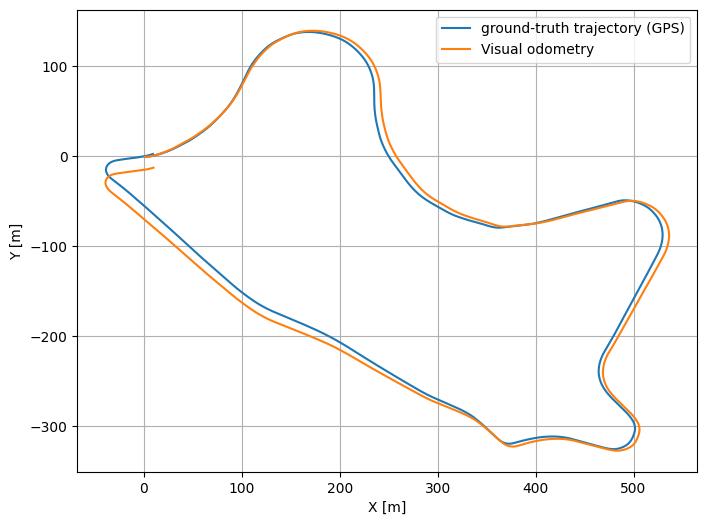

In [2]:
root_path = "../../"

file_export_path = os.path.join(root_path, "exports/particle_filter")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")

pose_dir = os.path.join(kitti_root_dir, "poses")
calib_dir = os.path.join(kitti_root_dir, "sequences", "09")

kitti_dataset = "0033"

data = DataLoader(sequence_nr=kitti_dataset, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

In [3]:
poses = pd.read_csv(os.path.join(pose_dir, "09.txt"), delimiter=' ', header=None)
calib_path = os.path.join(calib_dir, "calib.txt")

#gps data obtained from pose x rotation matrix 
gps = data.GPS_measurements_in_meter_original.copy() 
#raw gps data converted from lla to local coord(East-North-Up)
raw = data.GPS_from_raw_data_in_meter.copy() 

In [15]:
# Extract translation vector from pose data provided by the visual odometry dataset in Kitti.

gt = np.zeros((len(poses), 3, 4))
for i in range(len(poses)):
    gt[i] = np.array(poses.iloc[i]).reshape((3, 4))
gps_gt = gt[:, :, 3]
# This is not lla, it is translated into cartesian coordinate in meter.
# the translational part (3x1 vector of column 4) corresponds to the pose of the left camera coordinate system in the i'th frame with respect to the first (=0th) frame.
vo_pose = data.transform_gps_data_into_imu_coord(gps_gt)
vo_pose

Transform GPS data into imu coordinate.


array([[ 1.14259534, -0.8096661 ,  0.2296859 ],
       [ 1.43087229, -0.82961907,  0.23320554],
       [ 1.72368929, -0.84556089,  0.23487489],
       ...,
       [ 7.91784827,  1.77617269, -2.95616076],
       [ 8.60377678,  2.00521432, -2.95460759],
       [ 9.29690824,  2.23995254, -2.95385594]])

In [19]:
# Check if pose data in visual odometory dataset meets the gt
np.sum(gps - vo_pose)

0.0

In [5]:
# Extract translation vector from oxts data in Kitti raw dataset

p = []
for index, oxts_data in enumerate(data.dataset.oxts):
    if index < data.N_original:
        pose = oxts_data.T_w_imu
        p.append(pose)

p = np.array(p)
oxts_gt = p[:, :, 3][:, :3]
oxts_gt

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.27052486, -0.14825607,  0.01792908],
       [ 0.51904658, -0.28669154,  0.03144836],
       ...,
       [ 7.14635564, -1.12660423, -2.85975647],
       [ 7.90126648, -1.26345292, -2.8293457 ],
       [ 8.59286972, -1.38318758, -2.79959106]])

In [65]:
def z():
    theta = np.pi / 6.5
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c, s, 0],
        [-s, c, 0],
        [0, 0, 1]
    ])
    
rot = z()
rot_inv = np.linalg.inv(rot)

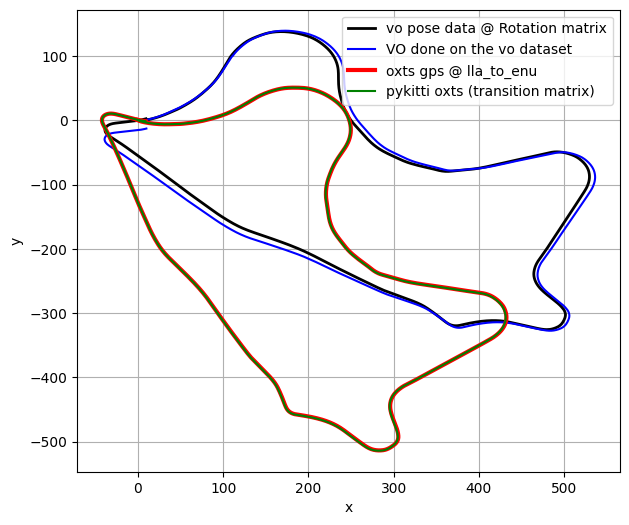

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(7,6))

x, y, _ =  vo_pose.T
ax.plot(x, y, label='vo pose data @ Rotation matrix', color="black", lw=2)

x, y, _ =  data.VO_measurements_original.T
ax.plot(x, y, label='VO done on the vo dataset', color="blue")

xs, ys, _ = raw.T
ax.plot(xs, ys, label='oxts gps @ lla_to_enu', color="red", lw=3)
xs, ys, _ = oxts_gt.T
ax.plot(xs, ys, label='pykitti oxts (transition matrix)', color="green")

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid()

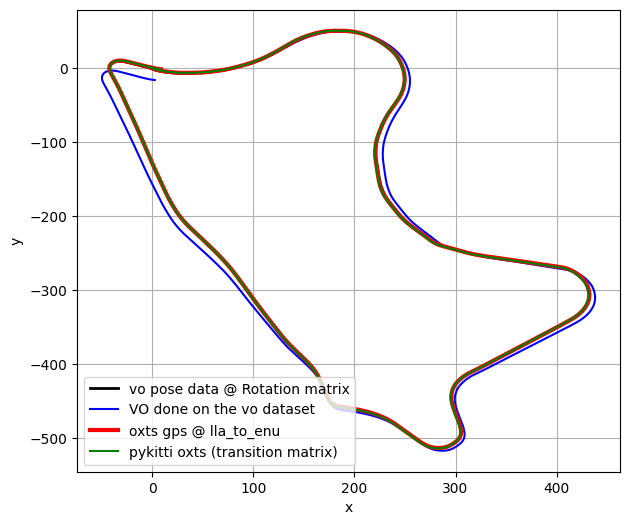

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(7,6))

x, y, _ =  rot @ vo_pose.T
ax.plot(x, y, label='vo pose data @ Rotation matrix', color="black", lw=2)

x, y, _ =  rot @ data.VO_measurements_original.T
ax.plot(x, y, label='VO done on the vo dataset', color="blue")

xs, ys, _ = raw.T
ax.plot(xs, ys, label='oxts gps @ lla_to_enu', color="red", lw=3)
xs, ys, _ = oxts_gt.T
ax.plot(xs, ys, label='pykitti oxts (transition matrix)', color="green")

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid()

## Check other sequenece

Data size: 271
Shape:
GPS: (271, 3)
VO: (271, 3)
IMU: (271, 6)
INS angle: (271, 3)
INS velocity: (271, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


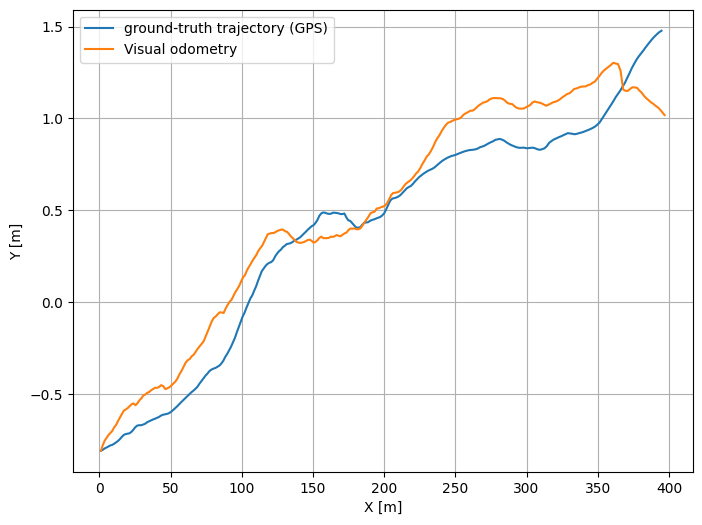

In [30]:
kitti_dataset = "0016"

data = DataLoader(sequence_nr=kitti_dataset, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

In [35]:
poses = pd.read_csv(os.path.join(pose_dir, "04.txt"), delimiter=' ', header=None)

#gps data obtained from pose x rotation matrix 
gps = data.GPS_measurements_in_meter_original.copy() 
#raw gps data converted from lla to local coord(East-North-Up)
raw = data.GPS_from_raw_data_in_meter.copy() 

In [37]:
# Extract translation vector from pose data provided by the visual odometry dataset in Kitti.

gt = np.zeros((len(poses), 3, 4))
for i in range(len(poses)):
    gt[i] = np.array(poses.iloc[i]).reshape((3, 4))
gps_gt = gt[:, :, 3]
# This is not lla, it is translated into cartesian coordinate in meter.
# the translational part (3x1 vector of column 4) corresponds to the pose of the left camera coordinate system in the i'th frame with respect to the first (=0th) frame.
vo_pose = data.transform_gps_data_into_imu_coord(gps_gt)
# Check if pose data in visual odometory dataset meets the gt
np.sum(gps - vo_pose)

Transform GPS data into imu coordinate.


0.0

In [39]:
# Extract translation vector from oxts data in Kitti raw dataset

p = []
for index, oxts_data in enumerate(data.dataset.oxts):
    if index < data.N_original:
        pose = oxts_data.T_w_imu
        p.append(pose)

p = np.array(p)
oxts_gt = p[:, :, 3][:, :3]

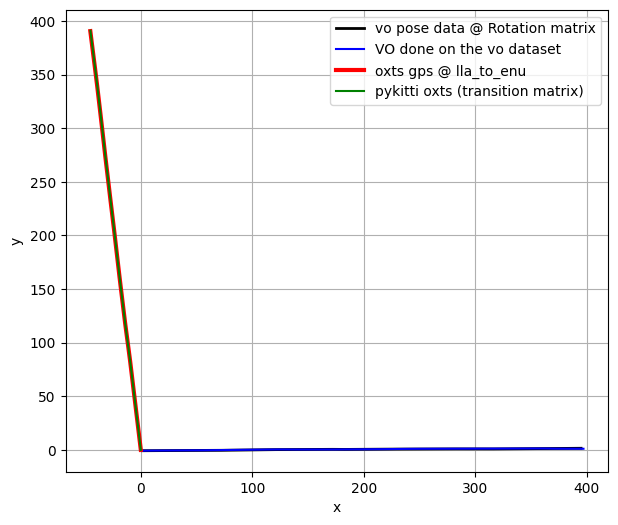

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(7,6))

x, y, _ = vo_pose.T
ax.plot(x, y, label='vo pose data @ Rotation matrix', color="black", lw=2)

x, y, _ = data.VO_measurements_original.T
ax.plot(x, y, label='VO done on the vo dataset', color="blue")

xs, ys, _ = raw.T
ax.plot(xs, ys, label='oxts gps @ lla_to_enu', color="red", lw=3)
xs, ys, _ = oxts_gt.T
ax.plot(xs, ys, label='pykitti oxts (transition matrix)', color="green")

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid()

In [ ]:
def z2():
    theta = np.pi / 2
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c, s, 0],
        [-s, c, 0],
        [0, 0, 1]
    ])
    
rot_04 = z2()
rot_04_inv = np.linalg.inv(rot_04)

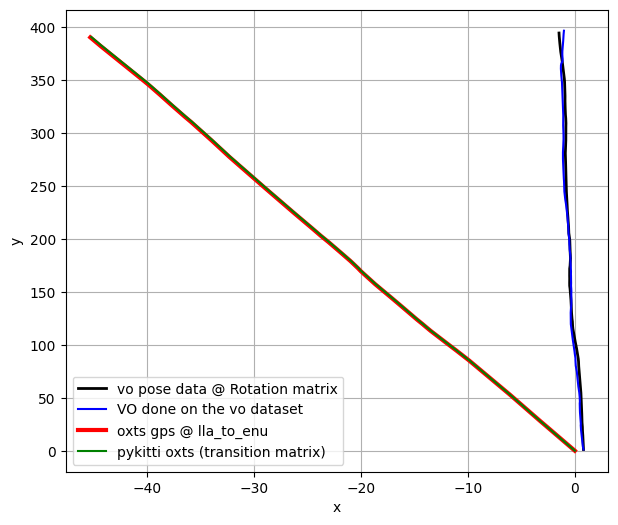

In [71]:
fig, ax = plt.subplots(1, 1, figsize=(7,6))

x, y, _ = rot_04_inv @ vo_pose.T
ax.plot(x, y, label='vo pose data @ Rotation matrix', color="black", lw=2)

x, y, _ = rot_04_inv @ data.VO_measurements_original.T
ax.plot(x, y, label='VO done on the vo dataset', color="blue")

xs, ys, _ = raw.T
ax.plot(xs, ys, label='oxts gps @ lla_to_enu', color="red", lw=3)
xs, ys, _ = oxts_gt.T
ax.plot(xs, ys, label='pykitti oxts (transition matrix)', color="green")

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid()